# Reward per episode

plot the cumulative reward per episode against terminated episodes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['font.size'] = 13

In [2]:
root_folder = 'run/2026-5-10_19-12-55_745nN_400ms_RL'

## One env

In [7]:
df = pd.read_excel(root_folder + '/consolidated_episodes.xlsx')

In [8]:
df['progress_mean'] = df['cum_progress'] / df['steps']
df['progress_roll_mean'] = df['progress_mean'].rolling(window=5, center=True).mean()
df['energy_mean'] = df['cum_energy_efficiency'] / df['steps']
df['energy_roll_mean'] = df['energy_mean'].rolling(window=5, center=True).mean()
df['smoothness_mean'] = df['cum_smoothness'] / df['steps']
df['smoothness_roll_mean'] = df['smoothness_mean'].rolling(window=5, center=True).mean()
df['steps_mean'] = df['steps']
df['steps_roll_mean'] = df['steps_mean'].rolling(window=5, center=True).mean()
df['progress_roll_std'] = df['progress_mean'].rolling(window=5, center=True).std()
df['energy_roll_std'] = df['energy_mean'].rolling(window=5, center=True).std()
df['smoothness_roll_std'] = df['smoothness_mean'].rolling(window=5, center=True).std()

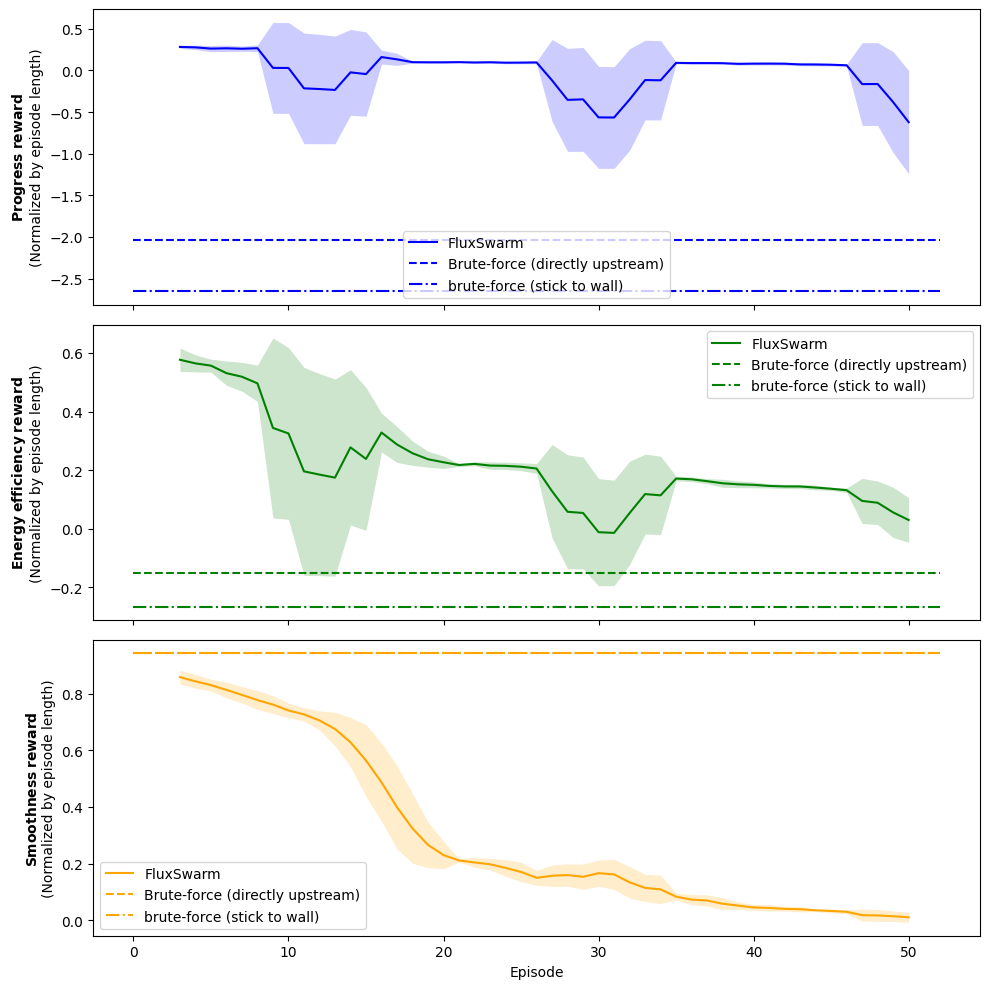

In [9]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df['episode'], df['progress_roll_mean'], c='b', label='FluxSwarm')
ax[0].fill_between(df['episode'], df['progress_roll_mean'] - df['progress_roll_std'], df['progress_roll_mean'] + df['progress_roll_std'], alpha=0.2, color='b', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df['episode'], df['energy_roll_mean'], c='g', label='FluxSwarm')
ax[1].fill_between(df['episode'], df['energy_roll_mean'] - df['energy_roll_std'], df['energy_roll_mean'] + df['energy_roll_std'], alpha=0.2, color='g', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df['episode'], df['smoothness_roll_mean'], c='orange', label='FluxSwarm')
ax[2].fill_between(df['episode'], df['smoothness_roll_mean'] - df['smoothness_roll_std'], df['smoothness_roll_mean'] + df['smoothness_roll_std'], alpha=0.2, color='orange', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Episode')

# Brute-force control (a_x = -1, a_y = 0)
ax[0].plot([0,max(df['episode'])], [-2.039039765,-2.039039765], c='b', linestyle='--', label='Brute-force (directly upstream)')
ax[1].plot([0,max(df['episode'])], [-0.151423235,-0.151423235], c='g', linestyle='--', label='Brute-force (directly upstream)')
ax[2].plot([0,max(df['episode'])], [0.941176471,0.941176471], c='orange', linestyle='--', label='Brute-force (directly upstream)')

# Smart brute-force control (a_x = -1/sqrt(2), a_y = 1/sqrt(2))
ax[0].plot([0,max(df['episode'])], [-2.651532706,-2.651532706], c='b', linestyle='-.', label='brute-force (stick to wall)')
ax[1].plot([0,max(df['episode'])], [-0.265852882,-0.265852882], c='g', linestyle='-.', label='brute-force (stick to wall)')
ax[2].plot([0,max(df['episode'])], [0.941176471,0.941176471], c='orange', linestyle='-.', label='brute-force (stick to wall)')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.savefig('reward per episode.png', dpi=300)
plt.show()

In [14]:
df['progress_roll_mean'] = df['cum_progress'].rolling(window=10, center=True).mean()
df['energy_roll_mean'] = df['cum_energy_efficiency'].rolling(window=10, center=True).mean()
df['smoothness_roll_mean'] = df['cum_smoothness'].rolling(window=10, center=True).mean()
df['progress_roll_std'] = df['cum_progress'].rolling(window=10, center=True).std()
df['energy_roll_std'] = df['cum_energy_efficiency'].rolling(window=10, center=True).std()
df['smoothness_roll_std'] = df['cum_smoothness'].rolling(window=10, center=True).std()
df['cum_steps'] = df['steps'].cumsum()

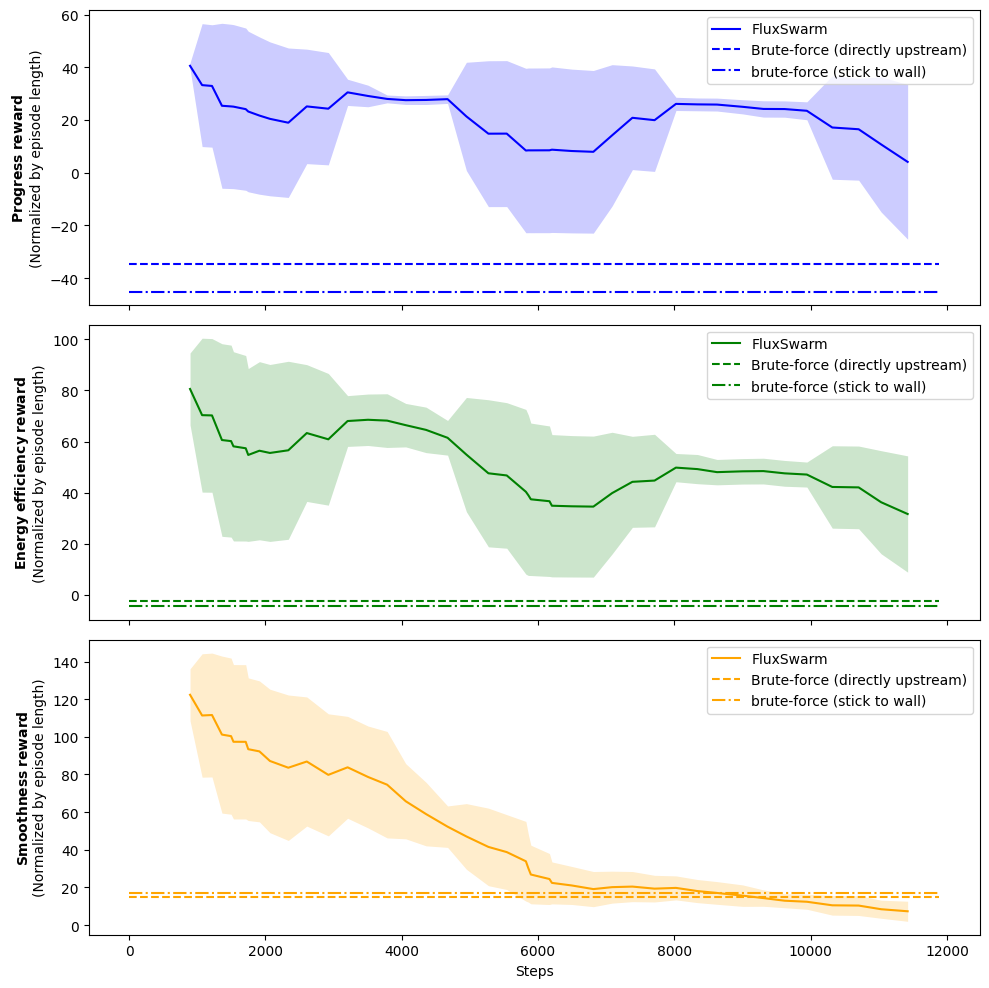

In [15]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df['cum_steps'], df['progress_roll_mean'], c='b', label='FluxSwarm')
ax[0].fill_between(df['cum_steps'], df['progress_roll_mean'] - df['progress_roll_std'], df['progress_roll_mean'] + df['progress_roll_std'], alpha=0.2, color='b', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df['cum_steps'], df['energy_roll_mean'], c='g', label='FluxSwarm')
ax[1].fill_between(df['cum_steps'], df['energy_roll_mean'] - df['energy_roll_std'], df['energy_roll_mean'] + df['energy_roll_std'], alpha=0.2, color='g', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df['cum_steps'], df['smoothness_roll_mean'], c='orange', label='FluxSwarm')
ax[2].fill_between(df['cum_steps'], df['smoothness_roll_mean'] - df['smoothness_roll_std'], df['smoothness_roll_mean'] + df['smoothness_roll_std'], alpha=0.2, color='orange', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Steps')

# Brute-force control (a_x = -1, a_y = 0)
ax[0].plot([0,max(df['cum_steps'])], [-34.66368,-34.66368], c='b', linestyle='--', label='Brute-force (directly upstream)')
ax[1].plot([0,max(df['cum_steps'])], [-2.574195,-2.574195], c='g', linestyle='--', label='Brute-force (directly upstream)')
ax[2].plot([0,max(df['cum_steps'])], [15,15], c='orange', linestyle='--', label='Brute-force (directly upstream)')

# Smart brute-force control (a_x = -1/sqrt(2), a_y = 1/sqrt(2))
ax[0].plot([0,max(df['cum_steps'])], [-45.076,-45.076], c='b', linestyle='-.', label='brute-force (stick to wall)')
ax[1].plot([0,max(df['cum_steps'])], [-4.51949,-4.51949], c='g', linestyle='-.', label='brute-force (stick to wall)')
ax[2].plot([0,max(df['cum_steps'])], [17,17], c='orange', linestyle='-.', label='brute-force (stick to wall)')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.savefig('reward per episode.png', dpi=300)
plt.show()

## Per episode length

In [13]:
root_folder = 'run/2026-5-13_13-51-45_745nN_400ms_RL'

In [14]:
df_progress = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_progress_per_ste')
df_progress.columns = ['episode', 'mean', 'std']
df_energy = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_energy_efficienc')
df_energy.columns = ['episode', 'mean', 'std']
df_smoothness = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_smoothness_per_s')
df_smoothness.columns = ['episode', 'mean', 'std']
df_steps = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='agg_steps')
df_steps.columns = ['episode', 'mean', 'std']

In [15]:
df_progress['roll_mean'] = df_progress['mean'].rolling(window=5, center=True).mean()
df_progress['roll_std'] = df_progress['std'].rolling(window=5, center=True).mean()
df_energy['roll_mean'] = df_energy['mean'].rolling(window=5, center=True).mean()
df_energy['roll_std'] = df_energy['std'].rolling(window=5, center=True).mean()
df_smoothness['roll_mean'] = df_smoothness['mean'].rolling(window=5, center=True).mean()
df_smoothness['roll_std'] = df_smoothness['std'].rolling(window=5, center=True).mean()
df_steps['roll_mean'] = df_steps['mean'].rolling(window=5, center=True).mean()
df_steps['roll_std'] = df_steps['std'].rolling(window=5, center=True).mean()


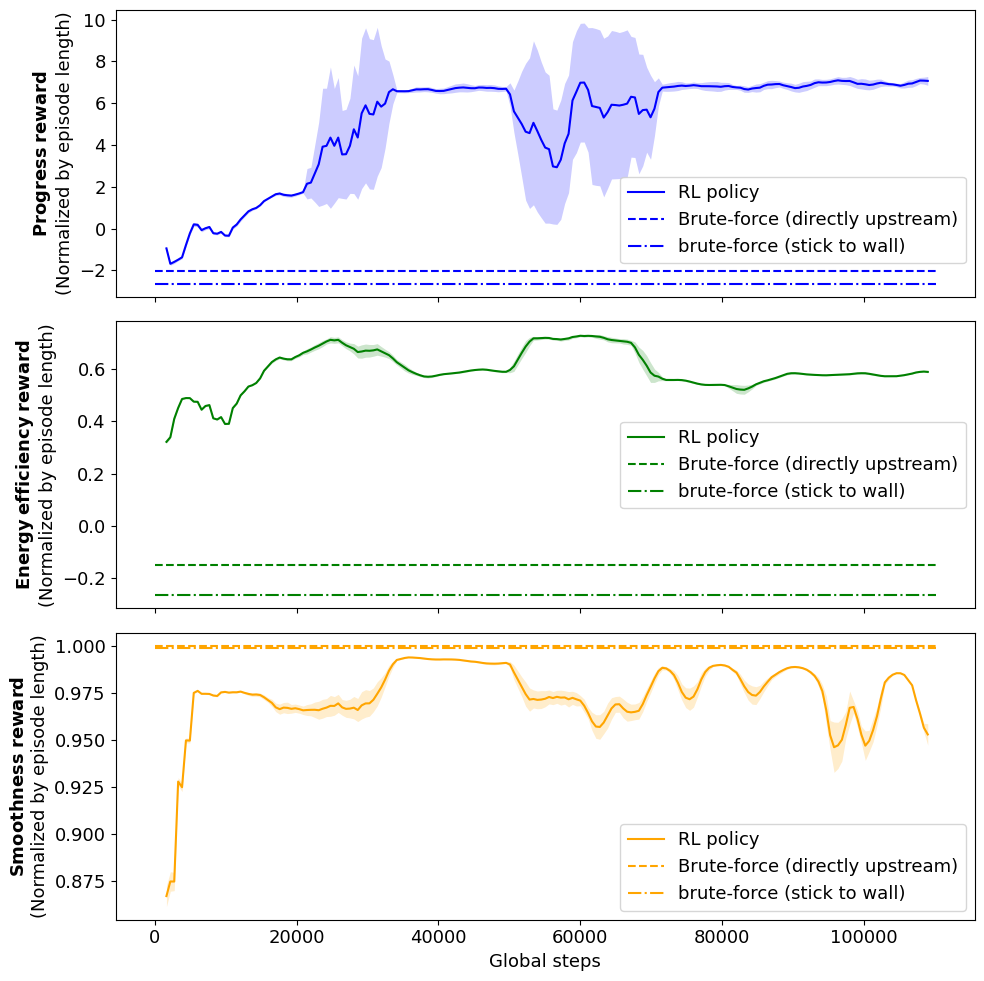

In [28]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df_progress['episode'], df_progress['roll_mean'], c='b', label='RL policy')
ax[0].fill_between(df_progress['episode'], df_progress['roll_mean'] - df_progress['roll_std'], df_progress['roll_mean'] + df_progress['roll_std'], alpha=0.2, color='b', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df_energy['episode'], df_energy['roll_mean'], c='g', label='RL policy')
ax[1].fill_between(df_energy['episode'], df_energy['roll_mean'] - df_energy['roll_std'], df_energy['roll_mean'] + df_energy['roll_std'], alpha=0.2, color='g', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df_smoothness['episode'], df_smoothness['roll_mean'], c='orange', label='RL policy')
ax[2].fill_between(df_smoothness['episode'], df_smoothness['roll_mean'] - df_smoothness['roll_std'], df_smoothness['roll_mean'] + df_smoothness['roll_std'], alpha=0.2, color='orange', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Global steps')

# Brute-force control (a_x = -1, a_y = 0)
ax[0].plot([0,max(df_progress['episode'])], [-2.039039765,-2.039039765], c='b', linestyle='--', label='Brute-force (directly upstream)')
ax[1].plot([0,max(df_energy['episode'])], [-0.151423235,-0.151423235], c='g', linestyle='--', label='Brute-force (directly upstream)')
ax[2].plot([0,max(df_smoothness['episode'])], [1,1], c='orange', linestyle='--', label='Brute-force (directly upstream)')

# Smart brute-force control (a_x = -1/sqrt(2), a_y = 1/sqrt(2))
ax[0].plot([0,max(df_progress['episode'])], [-2.651532706,-2.651532706], c='b', linestyle='-.', label='brute-force (stick to wall)')
ax[1].plot([0,max(df_energy['episode'])], [-0.265852882,-0.265852882], c='g', linestyle='-.', label='brute-force (stick to wall)')
ax[2].plot([0,max(df_smoothness['episode'])], [0.999,0.999], c='orange', linestyle='-.', label='brute-force (stick to wall)')

# ax[2].set_ylim(0,1.1)

ax[0].legend(loc='upper right', bbox_to_anchor=(1,0.45))
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.savefig('reward per episode.png', dpi=300)
plt.show()

## Universal steps

In [42]:
df_progress = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='agg_cum_progress')
df_progress.columns = ['episode', 'mean', 'std']
df_energy = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='agg_cum_energy_efficiency')
df_energy.columns = ['episode', 'mean', 'std']
df_smoothness = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='agg_cum_smoothness')
df_smoothness.columns = ['episode', 'mean', 'std']
df_steps = pd.read_excel(root_folder + '/consolidated_episodes.xlsx', sheet_name='agg_steps')
df_steps.columns = ['episode', 'mean', 'std']

In [43]:
df_progress['roll_mean'] = df_progress['mean'].rolling(window=5, center=True).mean()
df_progress['roll_std'] = df_progress['std'].rolling(window=5, center=True).mean()
df_energy['roll_mean'] = df_energy['mean'].rolling(window=5, center=True).mean()
df_energy['roll_std'] = df_energy['std'].rolling(window=5, center=True).mean()
df_smoothness['roll_mean'] = df_smoothness['mean'].rolling(window=5, center=True).mean()
df_smoothness['roll_std'] = df_smoothness['std'].rolling(window=5, center=True).mean()
df_steps['roll_mean'] = df_steps['mean'].rolling(window=5, center=True).mean()
df_steps['roll_std'] = df_steps['std'].rolling(window=5, center=True).mean()

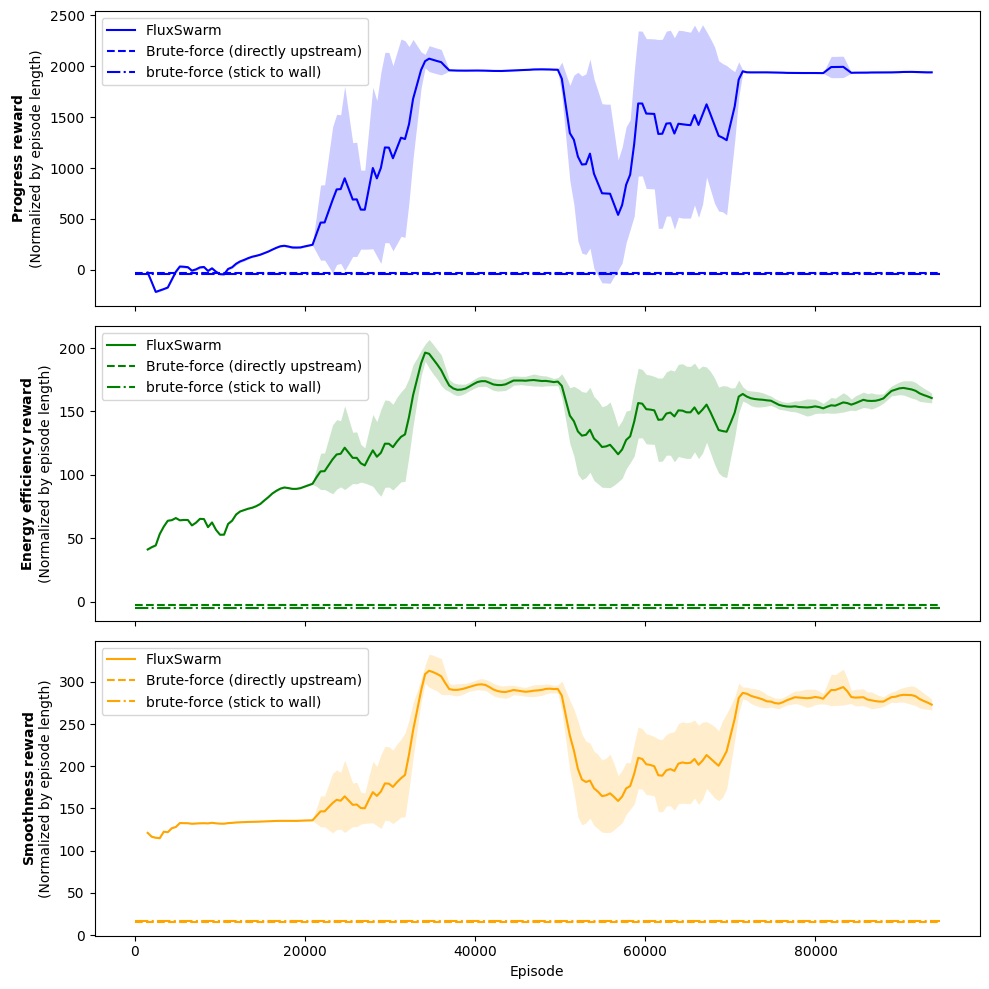

In [44]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df_progress['episode'], df_progress['roll_mean'], c='b', label='FluxSwarm')
ax[0].fill_between(df_progress['episode'], df_progress['roll_mean'] - df_progress['roll_std'], df_progress['roll_mean'] + df_progress['roll_std'], alpha=0.2, color='b', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df_energy['episode'], df_energy['roll_mean'], c='g', label='FluxSwarm')
ax[1].fill_between(df_energy['episode'], df_energy['roll_mean'] - df_energy['roll_std'], df_energy['roll_mean'] + df_energy['roll_std'], alpha=0.2, color='g', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df_smoothness['episode'], df_smoothness['roll_mean'], c='orange', label='FluxSwarm')
ax[2].fill_between(df_smoothness['episode'], df_smoothness['roll_mean'] - df_smoothness['roll_std'], df_smoothness['roll_mean'] + df_smoothness['roll_std'], alpha=0.2, color='orange', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Episode')

# Brute-force control (a_x = -1, a_y = 0)
ax[0].plot([0,max(df_progress['episode'])], [-34.66368,-34.66368], c='b', linestyle='--', label='Brute-force (directly upstream)')
ax[1].plot([0,max(df_energy['episode'])], [-2.574195,-2.574195], c='g', linestyle='--', label='Brute-force (directly upstream)')
ax[2].plot([0,max(df_smoothness['episode'])], [15,15], c='orange', linestyle='--', label='Brute-force (directly upstream)')

# Smart brute-force control (a_x = -1/sqrt(2), a_y = 1/sqrt(2))
ax[0].plot([0,max(df_progress['episode'])], [-45.076,-45.076], c='b', linestyle='-.', label='brute-force (stick to wall)')
ax[1].plot([0,max(df_energy['episode'])], [-4.51949,-4.51949], c='g', linestyle='-.', label='brute-force (stick to wall)')
ax[2].plot([0,max(df_smoothness['episode'])], [17,17], c='orange', linestyle='-.', label='brute-force (stick to wall)')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.savefig('reward per episode.png', dpi=300)
plt.show()

## Infulence of PCGrad

In [30]:
with_root_folder = 'run/2026-5-13_13-51-45_745nN_400ms_RL'
without_root_folder = 'run/2026-5-15_20-39-57'

In [31]:
df_progress_with = pd.read_excel(with_root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_progress_per_ste')
df_progress_with.columns = ['episode', 'mean', 'std']
df_energy_with = pd.read_excel(with_root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_energy_efficienc')
df_energy_with.columns = ['episode', 'mean', 'std']
df_smoothness_with = pd.read_excel(with_root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_smoothness_per_s')
df_smoothness_with.columns = ['episode', 'mean', 'std']

df_progress_without = pd.read_excel(without_root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_progress_per_ste')
df_progress_without.columns = ['episode', 'mean', 'std']
df_energy_without = pd.read_excel(without_root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_energy_efficienc')
df_energy_without.columns = ['episode', 'mean', 'std']
df_smoothness_without = pd.read_excel(without_root_folder + '/consolidated_episodes.xlsx', sheet_name='per_step_cum_smoothness_per_s')
df_smoothness_without.columns = ['episode', 'mean', 'std']

In [32]:
df_progress_with['roll_mean'] = df_progress_with['mean'].rolling(window=5, center=True).mean()
df_progress_with['roll_std'] = df_progress_with['std'].rolling(window=5, center=True).mean()
df_energy_with['roll_mean'] = df_energy_with['mean'].rolling(window=5, center=True).mean()
df_energy_with['roll_std'] = df_energy_with['std'].rolling(window=5, center=True).mean()
df_smoothness_with['roll_mean'] = df_smoothness_with['mean'].rolling(window=5, center=True).mean()
df_smoothness_with['roll_std'] = df_smoothness_with['std'].rolling(window=5, center=True).mean()
df_progress_without['roll_mean'] = df_progress_without['mean'].rolling(window=5, center=True).mean()
df_progress_without['roll_std'] = df_progress_without['std'].rolling(window=5, center=True).mean()
df_energy_without['roll_mean'] = df_energy_without['mean'].rolling(window=5, center=True).mean()
df_energy_without['roll_std'] = df_energy_without['std'].rolling(window=5, center=True).mean()
df_smoothness_without['roll_mean'] = df_smoothness_without['mean'].rolling(window=5, center=True).mean()
df_smoothness_without['roll_std'] = df_smoothness_without['std'].rolling(window=5, center=True).mean()

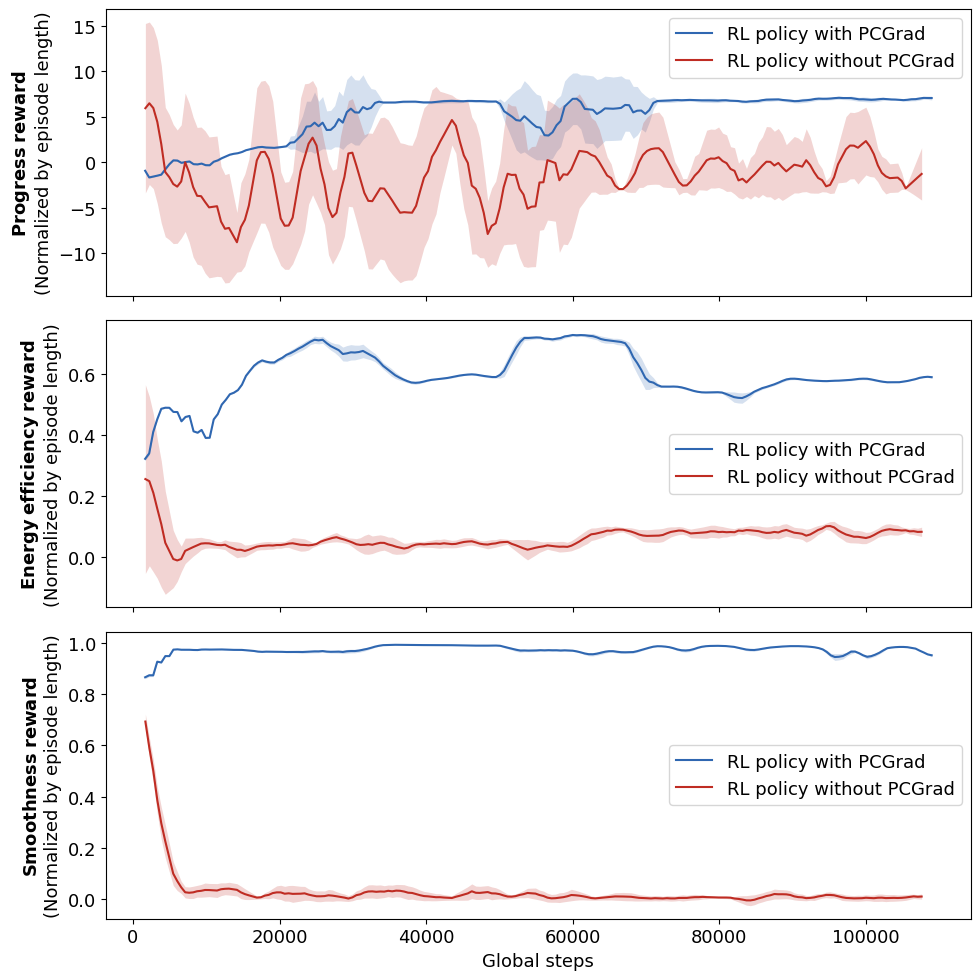

In [33]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df_progress_with['episode'], df_progress_with['roll_mean'], c='#2F67B1', label='RL policy with PCGrad')
ax[0].fill_between(df_progress_with['episode'], df_progress_with['roll_mean'] - df_progress_with['roll_std'], df_progress_with['roll_mean'] + df_progress_with['roll_std'], alpha=0.2, color='#2F67B1', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df_energy_with['episode'], df_energy_with['roll_mean'], c='#2F67B1', label='RL policy with PCGrad')
ax[1].fill_between(df_energy_with['episode'], df_energy_with['roll_mean'] - df_energy_with['roll_std'], df_energy_with['roll_mean'] + df_energy_with['roll_std'], alpha=0.2, color='#2F67B1', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df_smoothness_with['episode'], df_smoothness_with['roll_mean'], c='#2F67B1', label='RL policy with PCGrad')
ax[2].fill_between(df_smoothness_with['episode'], df_smoothness_with['roll_mean'] - df_smoothness_with['roll_std'], df_smoothness_with['roll_mean'] + df_smoothness_with['roll_std'], alpha=0.2, color='#2F67B1', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Global steps')

ax[0].plot(df_progress_without['episode'], df_progress_without['roll_mean'], c='#BF2C23', label='RL policy without PCGrad')
ax[0].fill_between(df_progress_without['episode'], df_progress_without['roll_mean'] - df_progress_without['roll_std'], df_progress_without['roll_mean'] + df_progress_without['roll_std'], alpha=0.2, color='#BF2C23', linewidth=0)
ax[1].plot(df_energy_without['episode'], df_energy_without['roll_mean'], c='#BF2C23', label='RL policy without PCGrad')
ax[1].fill_between(df_energy_without['episode'], df_energy_without['roll_mean'] - df_energy_without['roll_std'], df_energy_without['roll_mean'] + df_energy_without['roll_std'], alpha=0.2, color='#BF2C23', linewidth=0)
ax[2].plot(df_smoothness_without['episode'], df_smoothness_without['roll_mean'], c='#BF2C23', label='RL policy without PCGrad')
ax[2].fill_between(df_smoothness_without['episode'], df_smoothness_without['roll_mean'] - df_smoothness_without['roll_std'], df_smoothness_without['roll_mean'] + df_smoothness_without['roll_std'], alpha=0.2, color='#BF2C23', linewidth=0)
ax[2].set_xlabel('Global steps')


ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.savefig('reward with without PCGrad.png', dpi=300)
plt.show()

## Phase analysis

In [3]:
df = pd.read_csv('run/2026-5-15_20-25-15/env_0_20260515_202515/MOMAPPO/2026-5-16_9-24-47/locations.csv').reset_index(drop=True)
last_episode = df['episode'].max()
new_df = pd.read_csv('run/2026-5-15_20-25-15/env_0_20260516_103730/MOMAPPO/2026-5-17_2-8-11/locations.csv')
new_df['episode'] = new_df['episode'] + last_episode
df = pd.concat([df, new_df]).reset_index(drop=True)

In [4]:
df

,timestep,episode,location_0_x,location_0_y,location_1_x,location_1_y,location_2_x,location_2_y,location_3_x,location_3_y,...,location_11_x,location_11_y,location_12_x,location_12_y,location_13_x,location_13_y,location_14_x,location_14_y,location_15_x,location_15_y
0,0.005,0,47.095000,0.580000,47.095000,1.410000,47.925000,0.580000,47.925000,1.410000,...,51.245000,1.410000,52.075000,0.580000,52.075000,1.410000,52.905000,0.580000,52.905000,1.410000
1,0.010,0,47.086453,0.579987,47.086459,1.410016,47.915903,0.580001,47.915894,1.409997,...,51.235912,1.409999,52.065903,0.579999,52.065892,1.410003,52.896452,0.580012,52.896458,1.409984
2,0.015,0,47.032702,0.577825,47.032925,1.407191,47.862663,0.573848,47.861295,1.414121,...,51.180732,1.407567,52.010395,0.580108,52.010352,1.409903,52.842503,0.579028,52.842498,1.410147
3,0.020,0,46.946363,0.563395,46.946799,1.393320,47.783042,0.546580,47.774633,1.434168,...,51.091153,1.394012,51.920376,0.576111,51.919169,1.408796,52.754539,0.572424,52.754940,1.407500
4,0.025,0,46.839489,0.531484,46.835957,1.385526,47.676908,0.534229,47.660616,1.450984,...,50.975787,1.372982,51.807978,0.553589,51.804109,1.412265,52.642789,0.563745,52.646963,1.385302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,39.980,418,51.825997,0.856874,59.047266,1.713576,50.178855,0.251795,54.828594,0.274431,...,56.349946,0.973969,52.736984,0.250156,59.088507,1.035854,53.796303,0.250759,61.482564,0.255038
15996,39.985,418,53.318088,0.844862,60.984697,1.740583,50.748882,0.309106,55.980105,0.255974,...,57.963775,0.590498,53.346886,0.255192,61.061270,1.109858,54.349150,0.251891,62.811839,0.250012
15997,39.990,418,54.916745,0.778787,62.906736,1.686499,51.343453,0.351649,57.090206,0.250027,...,59.880848,0.262143,54.107594,0.251912,63.199889,1.221169,54.963096,0.251910,64.143632,0.262858
15998,39.995,418,56.598407,0.692245,64.854973,1.597503,51.969757,0.364860,57.983232,0.256763,...,62.029170,0.252750,54.887944,0.251935,65.354761,1.292665,55.639859,0.251907,65.480767,0.253093


In [5]:
df['total_timestep'] = np.arange(0.005, 0.005 + len(df) * 0.005, 0.005)

In [6]:
df

,timestep,episode,location_0_x,location_0_y,location_1_x,location_1_y,location_2_x,location_2_y,location_3_x,location_3_y,...,location_11_y,location_12_x,location_12_y,location_13_x,location_13_y,location_14_x,location_14_y,location_15_x,location_15_y,total_timestep
0,0.005,0,47.095000,0.580000,47.095000,1.410000,47.925000,0.580000,47.925000,1.410000,...,1.410000,52.075000,0.580000,52.075000,1.410000,52.905000,0.580000,52.905000,1.410000,0.005
1,0.010,0,47.086453,0.579987,47.086459,1.410016,47.915903,0.580001,47.915894,1.409997,...,1.409999,52.065903,0.579999,52.065892,1.410003,52.896452,0.580012,52.896458,1.409984,0.010
2,0.015,0,47.032702,0.577825,47.032925,1.407191,47.862663,0.573848,47.861295,1.414121,...,1.407567,52.010395,0.580108,52.010352,1.409903,52.842503,0.579028,52.842498,1.410147,0.015
3,0.020,0,46.946363,0.563395,46.946799,1.393320,47.783042,0.546580,47.774633,1.434168,...,1.394012,51.920376,0.576111,51.919169,1.408796,52.754539,0.572424,52.754940,1.407500,0.020
4,0.025,0,46.839489,0.531484,46.835957,1.385526,47.676908,0.534229,47.660616,1.450984,...,1.372982,51.807978,0.553589,51.804109,1.412265,52.642789,0.563745,52.646963,1.385302,0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,39.980,418,51.825997,0.856874,59.047266,1.713576,50.178855,0.251795,54.828594,0.274431,...,0.973969,52.736984,0.250156,59.088507,1.035854,53.796303,0.250759,61.482564,0.255038,79.980
15996,39.985,418,53.318088,0.844862,60.984697,1.740583,50.748882,0.309106,55.980105,0.255974,...,0.590498,53.346886,0.255192,61.061270,1.109858,54.349150,0.251891,62.811839,0.250012,79.985
15997,39.990,418,54.916745,0.778787,62.906736,1.686499,51.343453,0.351649,57.090206,0.250027,...,0.262143,54.107594,0.251912,63.199889,1.221169,54.963096,0.251910,64.143632,0.262858,79.990
15998,39.995,418,56.598407,0.692245,64.854973,1.597503,51.969757,0.364860,57.983232,0.256763,...,0.252750,54.887944,0.251935,65.354761,1.292665,55.639859,0.251907,65.480767,0.253093,79.995


In [7]:
# Calculate center of mass for each timestep (averaging all 'location_*_x' and 'location_*_y' columns)
location_x_cols = [col for col in df.columns if col.startswith('location_') and col.endswith('_x')]
location_y_cols = [col for col in df.columns if col.startswith('location_') and col.endswith('_y')]

df['center_of_mass_x'] = df[location_x_cols].mean(axis=1)
df['center_of_mass_y'] = df[location_y_cols].mean(axis=1)

In [8]:
# Calculate the radius of gyration for each row and add as a new column
# First, compute the center of mass coordinates for each row (already done in cell 32)
# Now, compute the mean squared distance of each location to the center of mass, then take sqrt

location_x_cols = [col for col in df.columns if col.startswith('location_') and col.endswith('_x')]
location_y_cols = [col for col in df.columns if col.startswith('location_') and col.endswith('_y')]

def radius_of_gyration(row):
    xs = row[location_x_cols].values
    ys = row[location_y_cols].values
    com_x = row['center_of_mass_x']
    com_y = row['center_of_mass_y']
    return np.sqrt(np.mean((xs - com_x)**2 + (ys - com_y)**2))

df['radius_of_gyration'] = df.apply(radius_of_gyration, axis=1)

In [9]:
amplitude = 400
new_df = pd.DataFrame()
for episode in df['episode'].unique():
    df_episode = df[df['episode'] == episode]
    df_episode['inflow'] = amplitude * np.exp(-((np.linspace(0.005, 0.005 + (len(df_episode)-1) * 0.005, len(df_episode))%1.0-0.14)**2)/(2*0.04**2)) \
        - 0.1*amplitude * np.exp(-((np.linspace(0.005, 0.005 + (len(df_episode)-1) * 0.005, len(df_episode))%1.0-0.32)**2)/(2*0.035**2)) \
        + 0.05*amplitude * np.exp(-((np.linspace(0.005, 0.005 + (len(df_episode)-1) * 0.005, len(df_episode))%1.0-0.45)**2)/(2*0.05**2))
    new_df = pd.concat([new_df, df_episode])
df = new_df

In [10]:
df

,timestep,episode,location_0_x,location_0_y,location_1_x,location_1_y,location_2_x,location_2_y,location_3_x,location_3_y,...,location_13_y,location_14_x,location_14_y,location_15_x,location_15_y,total_timestep,center_of_mass_x,center_of_mass_y,radius_of_gyration,inflow
0,0.005,0,47.095000,0.580000,47.095000,1.410000,47.925000,0.580000,47.925000,1.410000,...,1.410000,52.905000,0.580000,52.905000,1.410000,0.005,50.000000,0.995000,1.946523,1.344675
1,0.010,0,47.086453,0.579987,47.086459,1.410016,47.915903,0.580001,47.915894,1.409997,...,1.410003,52.896452,0.580012,52.896458,1.409984,0.010,49.991038,0.995000,1.946522,2.034428
2,0.015,0,47.032702,0.577825,47.032925,1.407191,47.862663,0.573848,47.861295,1.414121,...,1.409903,52.842503,0.579028,52.842498,1.410147,0.015,49.936581,0.992684,1.946278,3.030271
3,0.020,0,46.946363,0.563395,46.946799,1.393320,47.783042,0.546580,47.774633,1.434168,...,1.408796,52.754539,0.572424,52.754940,1.407500,0.020,49.849900,0.980332,1.945217,4.443599
4,0.025,0,46.839489,0.531484,46.835957,1.385526,47.676908,0.534229,47.660616,1.450984,...,1.412265,52.642789,0.563745,52.646963,1.385302,0.025,49.739162,0.966564,1.945467,6.415084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,39.980,418,51.825997,0.856874,59.047266,1.713576,50.178855,0.251795,54.828594,0.274431,...,1.035854,53.796303,0.250759,61.482564,0.255038,79.980,54.528712,0.551606,3.280237,352.998758
15996,39.985,418,53.318088,0.844862,60.984697,1.740583,50.748882,0.309106,55.980105,0.255974,...,1.109858,54.349150,0.251891,62.811839,0.250012,79.985,55.696148,0.510547,3.682795,372.840990
15997,39.990,418,54.916745,0.778787,62.906736,1.686499,51.343453,0.351649,57.090206,0.250027,...,1.221169,54.963096,0.251910,64.143632,0.262858,79.990,56.913730,0.478051,4.146789,387.693278
15998,39.995,418,56.598407,0.692245,64.854973,1.597503,51.969757,0.364860,57.983232,0.256763,...,1.292665,55.639859,0.251907,65.480767,0.253093,79.995,58.145636,0.454510,4.665946,396.887141


In [11]:
# Shape anisotropy from the gyration-tensor eigenvalues: (λ_max - λ_min) / (λ_max + λ_min).
# 0 = isotropic, 1 = fully elongated (same covariance convention as radius_of_gyration).
def compute_anisotropy(row):
    xs = row[location_x_cols].values / 100
    ys = row[location_y_cols].values / 2
    xcom = row['center_of_mass_x'] / 100
    ycom = row['center_of_mass_y'] / 2
    X = np.stack([xs - xcom, ys - ycom], axis=1)
    cov = np.dot(X.T, X) / X.shape[0]
    evals = np.linalg.eigvalsh(cov)
    l_max, l_min = evals[::-1]
    denom = l_max + l_min
    if np.isclose(denom, 0.0):
        return 0.0
    return (l_max - l_min) / denom

df['anisotropy'] = df.apply(compute_anisotropy, axis=1)

In [12]:
df['dispersion_x'] = df[location_x_cols].std(axis=1)
df['dispersion_y'] = df[location_y_cols].std(axis=1)

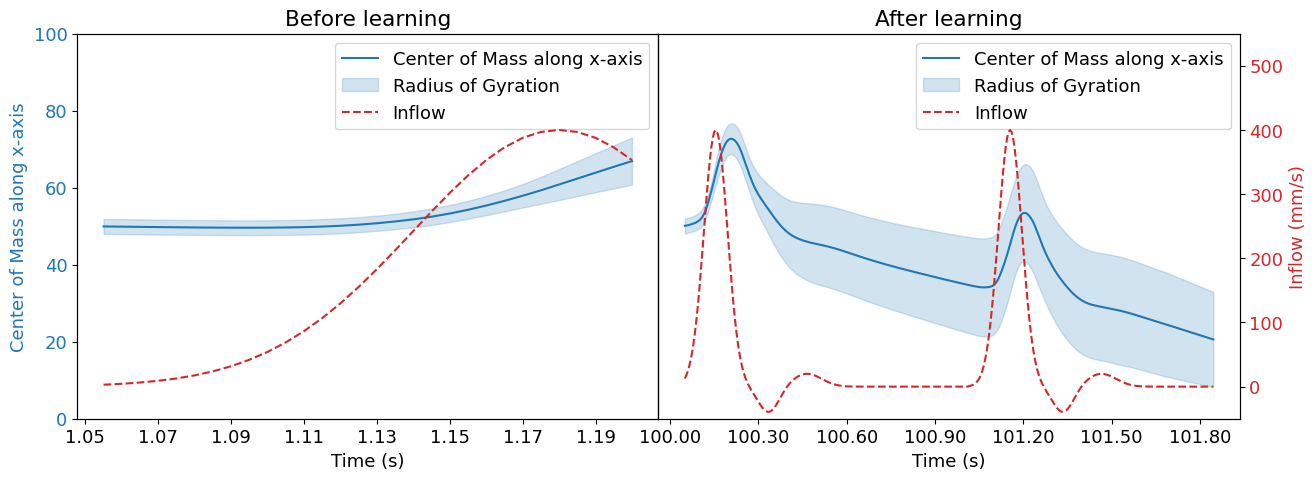

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Left subplot: 1-4 seconds
mask_left = (df['total_timestep'] >= 1.05) & (df['total_timestep'] <= 1.2)
df_left = df.loc[mask_left]

ax_left = axs[0]
color = 'tab:blue'
color2 = 'tab:red'
ax_left.set_xlabel('Time (s)')
old_ticks = np.arange(1.05, 1.2, 0.02)
ax_left.set_xticks(old_ticks)
ax_left.set_xticklabels([f"{v:.2f}" for v in old_ticks])
ax_left.set_ylabel('Center of Mass along x-axis', color=color)
line1, = ax_left.plot(df_left['total_timestep'], df_left['center_of_mass_x'], color=color, label='Center of Mass X')

# Add confidence interval: Center of mass x +/- radius of gyration (shaded area)
center = df_left['center_of_mass_x']
rg = df_left['radius_of_gyration']
time = df_left['total_timestep']
fill1 = ax_left.fill_between(
    time,
    center - rg,
    center + rg,
    color=color,
    alpha=0.2,
    label='Radius of Gyration'
)

ax_left.tick_params(axis='y', labelcolor=color)
ax_left.set_ylim(0, 100)  # Set center of mass axis from 0 to 100
ax_left.set_title('Before learning')

# Restore the inflow on the left subplot
ax_left_2 = ax_left.twinx()
# ax_left_2.set_ylabel('Inflow (mm/s)', color=color2)
line2, = ax_left_2.plot(df_left['total_timestep'], df_left['inflow'], color=color2, label='Inflow', linestyle='--')
ax_left_2.tick_params(axis='y', labelcolor=color2)
ax_left_2.tick_params(axis='y', which='major', length=0)
ax_left_2.set_yticklabels([])
ax_left_2.set_ylim(-50, 550)  # Set inflow axis from 0 to 500

# Collect handles/labels for legend
handles_left = [
    line1,
    fill1,
    line2
]
labels_left = [
    'Center of Mass along x-axis',
    'Radius of Gyration',
    'Inflow'
]
ax_left.legend(handles_left, labels_left, loc='upper right')

# Right subplot: 136-139 seconds
mask_right = (df['total_timestep'] >= 8.05) & (df['total_timestep'] <= 9.85)
df_right = df.loc[mask_right]

ax_right = axs[1]
color = 'tab:blue'
color2 = 'tab:red'
ax_right.set_xlabel('Time (s)')
old_ticks = np.arange(8.0, 9.95, 0.3)
ax_right.set_xticks(old_ticks)
new_labels = old_ticks + 92
ax_right.set_xticklabels([f"{v:.2f}" for v in new_labels])
# ax_right.xaxis.set_major_formatter('{x:.2f}')
# ax_right.set_ylabel('Center of Mass X', color=color)
line3, = ax_right.plot(df_right['total_timestep'], df_right['center_of_mass_x'], color=color, label='Center of Mass X')

# Add confidence interval: Center of mass x +/- radius of gyration (shaded area)
center_r = df_right['center_of_mass_x']
rg_r = df_right['radius_of_gyration']
time_r = df_right['total_timestep']
fill2 = ax_right.fill_between(
    time_r,
    center_r - rg_r,
    center_r + rg_r,
    color=color,
    alpha=0.2,
    label='Radius of Gyration'
)

ax_right.tick_params(axis='y', labelcolor=color)
ax_right.tick_params(axis='y', which='major', length=0)
ax_right.set_ylim(0, 100)  # Set center of mass axis from 0 to 100
ax_right.set_title('After learning')
ax_right_2 = ax_right.twinx()
ax_right_2.set_ylabel('Inflow (mm/s)', color=color2)
line4, = ax_right_2.plot(df_right['total_timestep'], df_right['inflow'], color=color2, label='Inflow', linestyle='--')
ax_right_2.tick_params(axis='y', labelcolor=color2)
ax_right_2.set_ylim(-50, 550)  # Set inflow axis from 0 to 500

# Collect handles/labels for legend
handles_right = [
    line3,
    fill2,
    line4
]
labels_right = [
    'Center of Mass along x-axis',
    'Radius of Gyration',
    'Inflow'
]
ax_right.legend(handles_right, labels_right, loc='upper right')
plt.subplots_adjust(wspace=0, hspace=0)
# plt.tight_layout()
plt.savefig('center of mass.png', dpi=300)
plt.show()


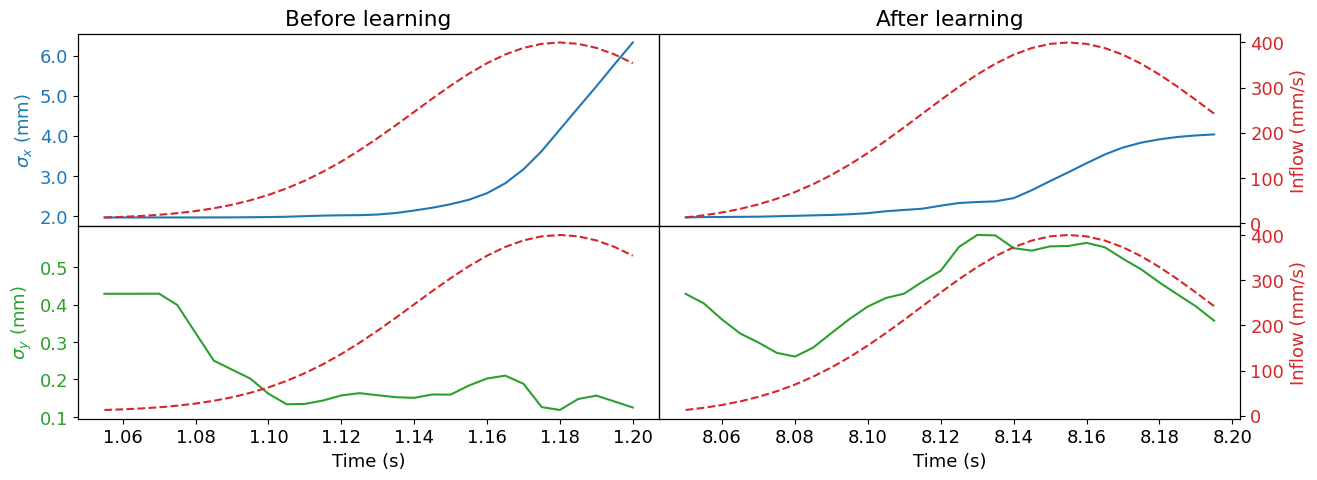

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(15, 5), sharex='col', sharey='row')

# Subplots for: 
# Row 0: X Dispersion (left=before, right=after)
# Row 1: Y Dispersion (left=before, right=after)

# Data masks
mask_left = (df['total_timestep'] >= 1.05) & (df['total_timestep'] <= 1.2)
df_left = df.loc[mask_left]
mask_right = (df['total_timestep'] >= 8.05) & (df['total_timestep'] <= 8.2)
df_right = df.loc[mask_right]

color_x = 'tab:blue'
color_y = 'tab:green'
color2 = 'tab:red'

# Top-left: X Dispersion before learning
ax_x_left = axs[0, 0]
# ax_x_left.set_xlabel('Time (s)')
ax_x_left.set_ylabel('$\sigma_x$ (mm)', color=color_x)
line1, = ax_x_left.plot(df_left['total_timestep'], df_left['dispersion_x'], color=color_x, label='X Dispersion')
ax_x_left.tick_params(axis='y', labelcolor=color_x)
ax_x_left.set_title('Before learning')
ax_x_left.yaxis.set_major_formatter('{x:.1f}')
# Twin y-axis for inflow
ax_x_left_2 = ax_x_left.twinx()
# ax_x_left_2.set_ylabel('Inflow (mm/s)', color=color2)
line2, = ax_x_left_2.plot(df_left['total_timestep'], df_left['inflow'], color=color2, label='Inflow', linestyle='--')
ax_x_left_2.tick_params(axis='y', which='major', length=0)

ax_x_left_2.set_yticklabels([])
# Legend
# ax_x_left.legend([line1, line2], ['Dispersion along x-axis', 'Inflow'], loc='upper left')

# Top-right: X Dispersion after learning
ax_x_right = axs[0, 1]
# ax_x_right.set_xlabel('Time (s)')
# ax_x_right.set_ylabel('X Dispersion', color=color_x)
line3, = ax_x_right.plot(df_right['total_timestep'], df_right['dispersion_x'], color=color_x, label='X Dispersion')
ax_x_right.tick_params(axis='y', which='major', length=0)
ax_x_right.set_title('After learning')
# Twin y-axis for inflow
ax_x_right_2 = ax_x_right.twinx()
ax_x_right_2.set_ylabel('Inflow (mm/s)', color=color2)
line4, = ax_x_right_2.plot(df_right['total_timestep'], df_right['inflow'], color=color2, label='Inflow', linestyle='--')
ax_x_right_2.tick_params(axis='y', labelcolor=color2)
# Legend
# ax_x_right.legend([line3, line4], ['Dispersion along x-axis', 'Inflow'], loc='upper left')

# Bottom-left: Y Dispersion before learning
ax_y_left = axs[1, 0]
ax_y_left.set_xlabel('Time (s)')
ax_y_left.set_ylabel('$\sigma_y$ (mm)', color=color_y)
line5, = ax_y_left.plot(df_left['total_timestep'], df_left['dispersion_y'], color=color_y, label='Y Dispersion')
ax_y_left.set_yticks(np.arange(0,0.6,0.1))
ax_y_left.tick_params(axis='y', labelcolor=color_y)
# ax_y_left.set_title('Y Dispersion: Before learning')
# Twin y-axis for inflow
ax_y_left_2 = ax_y_left.twinx()
# ax_y_left_2.set_ylabel('Inflow (mm/s)', color=color2)
line6, = ax_y_left_2.plot(df_left['total_timestep'], df_left['inflow'], color=color2, label='Inflow', linestyle='--')
ax_y_left_2.tick_params(axis='y', which='major', length=0)
ax_y_left_2.set_yticklabels([])
# Legend
# ax_y_left.legend([line5, line6], ['Dispersion along y-axis', 'Inflow'], loc='upper left')

# Bottom-right: Y Dispersion after learning
ax_y_right = axs[1, 1]
ax_y_right.set_xlabel('Time (s)')
# ax_y_right.set_ylabel('Y Dispersion', color=color_y)
line7, = ax_y_right.plot(df_right['total_timestep'], df_right['dispersion_y'], color=color_y, label='Y Dispersion')
ax_y_right.tick_params(axis='y', which='major', length=0)
# ax_y_right.set_title('Dispersion along y=axis: After learning')
# Twin y-axis for inflow
ax_y_right_2 = ax_y_right.twinx()
ax_y_right_2.set_ylabel('Inflow (mm/s)', color=color2)
line8, = ax_y_right_2.plot(df_right['total_timestep'], df_right['inflow'], color=color2, label='Inflow', linestyle='--')
ax_y_right_2.tick_params(axis='y', labelcolor=color2)
# Legend
# ax_y_right.legend([line7, line8], ['Dispersion along y-axis', 'Inflow'], loc='best')

fig.subplots_adjust(wspace=0, hspace=0) 

# plt.tight_layout()
plt.savefig('dispersion.png', dpi=300)
plt.show()